# RFM 분석 + 고객 세그먼테이션

## 분석 목표

**비즈니스 질문**: "누가 우리의 좋은 고객인가? 그리고 어떻게 다르게 대해야 하는가?"

## RFM이란

| 지표 | 의미 | 계산 |
|---|---|---|
| **R**ecency | 최근성 (얼마나 최근에 구매?) | 분석 기준일 - 마지막 구매일 |
| **F**requency | 빈도 (얼마나 자주?) | 총 구매 횟수 |
| **M**onetary | 금액 (얼마나 많이?) | 총 구매 금액 |

## 분석 흐름
1. 고객별 RFM 지표 계산
2. 분위수 기반 점수화 (1~5점)
3. RFM 점수 조합으로 세그먼트 분류
4. 세그먼트별 특성 분석 + 시각화
5. 비즈니스 인사이트 + 마케팅 제언

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib as mpl
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# 한글 폰트 강제 설정 (Windows)
font_path = 'C:/Windows/Fonts/malgun.ttf'
font_prop = fm.FontProperties(fname=font_path)
font_name = font_prop.get_name()

fm.fontManager.addfont(font_path)
mpl.rc('font', family=font_name)
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.family'] = font_name

sns.set_style("whitegrid", {"font.family": font_name})
plt.rcParams['figure.figsize'] = (12, 5)

# 1번 노트북에서 만든 데이터 로드
df = pd.read_csv('../data/analysis_dataset.csv')
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])

print(f"적용된 폰트: {font_name}")
print(f"데이터 로드 완료")
print(f"주문 수: {len(df):,}")
print(f"고객 수: {df['customer_unique_id'].nunique():,}")
print(f"기간: {df['order_purchase_timestamp'].min().date()} ~ {df['order_purchase_timestamp'].max().date()}")

적용된 폰트: Malgun Gothic
데이터 로드 완료
주문 수: 96,478
고객 수: 93,358
기간: 2016-09-15 ~ 2018-08-29


In [26]:
# 분석 기준일: 데이터의 마지막 날 + 1일
analysis_date = df['order_purchase_timestamp'].max() + pd.Timedelta(days=1)
print(f"분석 기준일: {analysis_date.date()}")

# 고객별 RFM 계산
rfm = df.groupby('customer_unique_id').agg(
    Recency=('order_purchase_timestamp', lambda x: (analysis_date - x.max()).days),
    Frequency=('order_id', 'nunique'),
    Monetary=('total_price', 'sum')
).reset_index()

print(f"\n RFM 데이터 생성 완료")
print(f"고객 수: {len(rfm):,}명")
print(f"\n샘플:")
print(rfm.head(10))
print(f"\n통계 요약:")
print(rfm[['Recency', 'Frequency', 'Monetary']].describe().round(2))

분석 기준일: 2018-08-30

 RFM 데이터 생성 완료
고객 수: 93,358명

샘플:
                 customer_unique_id  Recency  Frequency  Monetary
0  0000366f3b9a7992bf8c76cfdf3221e2      112          1    129.90
1  0000b849f77a49e4a4ce2b2a4ca5be3f      115          1     18.90
2  0000f46a3911fa3c0805444483337064      537          1     69.00
3  0000f6ccb0745a6a4b88665a16c9f078      321          1     25.99
4  0004aac84e0df4da2b147fca70cf8255      288          1    180.00
5  0004bd2a26a76fe21f786e4fbd80607f      146          1    154.00
6  00050ab1314c0e55a6ca13cf7181fecf      132          1     27.99
7  00053a61a98854899e70ed204dd4bafe      183          1    382.00
8  0005e1862207bf6ccc02e4228effd9a0      543          1    135.00
9  0005ef4cd20d2893f0d9fbd94d3c0d97      170          1    104.90

통계 요약:
        Recency  Frequency  Monetary
count  93358.00   93358.00  93358.00
mean     237.94       1.03    141.62
std      152.59       0.21    215.69
min        1.00       1.00      0.85
25%      114.00       1.00 

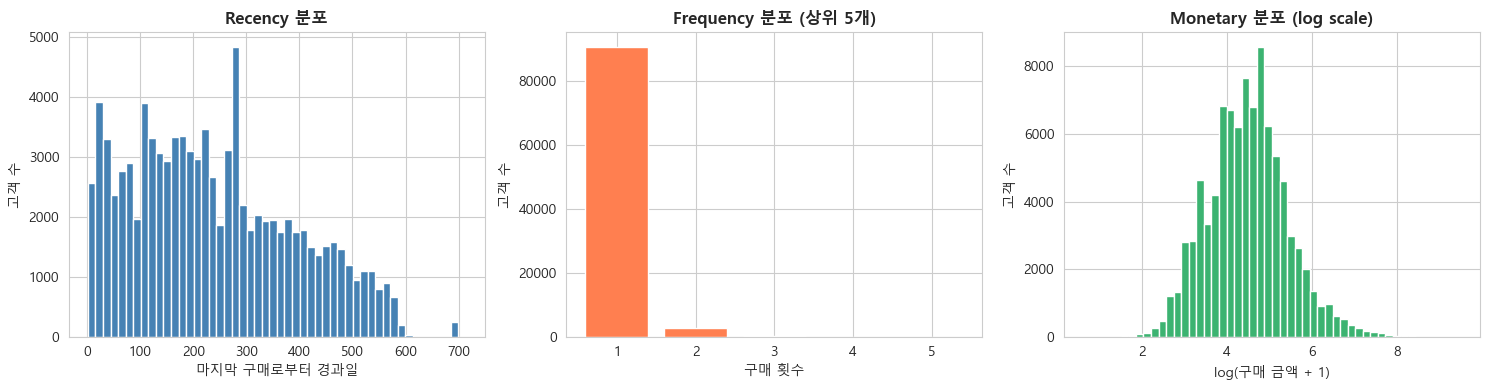


 발견:
1회만 구매한 고객: 90,557명 (97.0%)
-> 브라질 이커머스의 retention이 매우 낮음
-> 분석 시 신규/단발 고객 vs 재구매 고객 분리 필요


In [27]:
# RFM 각 지표의 분포 확인
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Recency
axes[0].hist(rfm['Recency'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Recency 분포', fontweight='bold')
axes[0].set_xlabel('마지막 구매로부터 경과일')
axes[0].set_ylabel('고객 수')

# Frequency
freq_counts = rfm['Frequency'].value_counts().sort_index()
axes[1].bar(freq_counts.index[:5], freq_counts.values[:5], color='coral', edgecolor='white')
axes[1].set_title('Frequency 분포 (상위 5개)', fontweight='bold')
axes[1].set_xlabel('구매 횟수')
axes[1].set_ylabel('고객 수')

# Monetary (log scale로 보기)
axes[2].hist(np.log1p(rfm['Monetary']), bins=50, color='mediumseagreen', edgecolor='white')
axes[2].set_title('Monetary 분포 (log scale)', fontweight='bold')
axes[2].set_xlabel('log(구매 금액 + 1)')
axes[2].set_ylabel('고객 수')

plt.tight_layout()
plt.show()

# 인사이트
single_purchase = (rfm['Frequency'] == 1).sum()
print(f"\n 발견:")
print(f"1회만 구매한 고객: {single_purchase:,}명 ({single_purchase/len(rfm)*100:.1f}%)")
print(f"-> 브라질 이커머스의 retention이 매우 낮음")
print(f"-> 분석 시 신규/단발 고객 vs 재구매 고객 분리 필요")

In [28]:
# 각 지표를 5분위로 나눠 1~5점 부여
# Recency는 작을수록 좋음 (최근 = 5점), Frequency/Monetary는 클수록 좋음

# Recency: 작을수록 5점
rfm['R_Score'] = pd.qcut(rfm['Recency'], q=5, labels=[5, 4, 3, 2, 1])

# Frequency: Frequency가 1인 사람이 너무 많아서 분위수 안 됨 -> 수동 분류
def freq_score(f):
    if f == 1: return 1
    elif f == 2: return 3
    elif f == 3: return 4
    else: return 5
rfm['F_Score'] = rfm['Frequency'].apply(freq_score)

# Monetary: 5분위
rfm['M_Score'] = pd.qcut(rfm['Monetary'], q=5, labels=[1, 2, 3, 4, 5])

# 정수형 변환
rfm['R_Score'] = rfm['R_Score'].astype(int)
rfm['M_Score'] = rfm['M_Score'].astype(int)

# RFM 통합 점수
rfm['RFM_Score'] = rfm['R_Score'] * 100 + rfm['F_Score'] * 10 + rfm['M_Score']
rfm['RFM_Sum'] = rfm['R_Score'] + rfm['F_Score'] + rfm['M_Score']

print("RFM 점수 부여 완료")
print(rfm.head())
print(f"\n점수 분포:")
print(rfm[['R_Score', 'F_Score', 'M_Score']].describe().round(2))

RFM 점수 부여 완료
                 customer_unique_id  Recency  Frequency  Monetary  R_Score  \
0  0000366f3b9a7992bf8c76cfdf3221e2      112          1    129.90        4   
1  0000b849f77a49e4a4ce2b2a4ca5be3f      115          1     18.90        4   
2  0000f46a3911fa3c0805444483337064      537          1     69.00        1   
3  0000f6ccb0745a6a4b88665a16c9f078      321          1     25.99        2   
4  0004aac84e0df4da2b147fca70cf8255      288          1    180.00        2   

   F_Score  M_Score  RFM_Score  RFM_Sum  
0        1        4        414        9  
1        1        1        411        6  
2        1        2        112        4  
3        1        1        211        4  
4        1        5        215        8  

점수 분포:
        R_Score   F_Score   M_Score
count  93358.00  93358.00  93358.00
mean       3.00      1.06      2.97
std        1.41      0.36      1.42
min        1.00      1.00      1.00
25%        2.00      1.00      2.00
50%        3.00      1.00      3.00
75%   

## 2. 고객 세그먼트 분류

RFM 점수 조합으로 고객을 의미 있는 그룹으로 분류한다.

### 분류 기준 설계

전형적인 8-segment 프레임워크는 F (Frequency) 점수에 강한 의존성을 가진다.
그러나 본 데이터셋은 96% 이상의 고객이 1회 구매에 그쳐 F가 분류력을 잃는다.
따라서 R (Recency)와 M (Monetary)을 주축으로 하는 5-segment 체계로 재설계한다.

### 분류 체계

| 세그먼트 | 정의 | 조건 |
|---|---|---|
| Champions | 최근에 구매했고 금액도 큰 고객 | R >= 4, M >= 4 |
| Loyal | 재구매 경험이 있는 고객 (충성도 핵심) | F >= 2 |
| Potential | 최근에 첫 구매한 고객 | R >= 4, F = 1 |
| At Risk | 과거 우수 고객인데 최근 안 옴 | R <= 2, M >= 4 |
| Hibernating | 휴면 단발 고객 | R <= 2, F = 1, M < 4 |
| Average | 그 외 평범한 고객 | 나머지 |

In [29]:
# 데이터 분포에 맞게 재설계한 5-segment 분류
def classify_segment(row):
    R, F, M = row['R_Score'], row['F_Score'], row['M_Score']
    
    # 재구매 경험이 있으면 Loyal 우선 (희소하지만 가장 가치 높음)
    if F >= 2:
        return 'Loyal'
    
    # F=1인 고객들을 R, M으로 분류
    if R >= 4 and M >= 4:
        return 'Champions'
    
    if R >= 4:
        return 'Potential'
    
    if R <= 2 and M >= 4:
        return 'At Risk'
    
    if R <= 2:
        return 'Hibernating'
    
    return 'Average'

rfm['Segment'] = rfm.apply(classify_segment, axis=1)

# 세그먼트 분포 확인
seg_counts = rfm['Segment'].value_counts()
seg_pct = (seg_counts / len(rfm) * 100).round(2)

result = pd.DataFrame({
    '고객 수': seg_counts,
    '비율(%)': seg_pct
})

print("세그먼트 분포")
print("=" * 50)
print(result)

세그먼트 분포
              고객 수  비율(%)
Segment                  
Hibernating  22582  24.19
Potential    21772  23.32
Average      18105  19.39
Champions    14452  15.48
At Risk      13646  14.62
Loyal         2801   3.00


In [30]:
# 세그먼트별 RFM 평균값 + 매출 기여도
seg_summary = rfm.groupby('Segment').agg(
    고객수=('customer_unique_id', 'count'),
    평균_Recency=('Recency', 'mean'),
    평균_Frequency=('Frequency', 'mean'),
    평균_Monetary=('Monetary', 'mean'),
    총_Monetary=('Monetary', 'sum')
).round(2)

total_revenue = rfm['Monetary'].sum()
seg_summary['매출비중(%)'] = (seg_summary['총_Monetary'] / total_revenue * 100).round(2)
seg_summary['고객비중(%)'] = (seg_summary['고객수'] / len(rfm) * 100).round(2)

seg_summary = seg_summary.sort_values('매출비중(%)', ascending=False)

print("세그먼트별 특성")
print("=" * 90)
print(seg_summary)

# 고객비중 대비 매출비중 비교 (효율성 지표)
seg_summary['매출/고객 비율'] = (seg_summary['매출비중(%)'] / seg_summary['고객비중(%)']).round(2)
print("\n매출비중 / 고객비중 (1.0 초과 = 평균 이상의 가치)")
print(seg_summary[['고객비중(%)', '매출비중(%)', '매출/고객 비율']].sort_values('매출/고객 비율', ascending=False))

세그먼트별 특성
               고객수  평균_Recency  평균_Frequency  평균_Monetary  총_Monetary  \
Segment                                                                 
Champions    14452       91.84          1.00       267.80  3870315.22   
At Risk      13646      394.82          1.00       278.15  3795588.68   
Average      18105      220.46          1.00       129.79  2349882.66   
Hibernating  22582      395.67          1.00        56.00  1264652.72   
Potential    21772       89.81          1.00        55.70  1212650.08   
Loyal         2801      220.29          2.11       260.05   728408.75   

             매출비중(%)  고객비중(%)  
Segment                        
Champions      29.27    15.48  
At Risk        28.71    14.62  
Average        17.77    19.39  
Hibernating     9.57    24.19  
Potential       9.17    23.32  
Loyal           5.51     3.00  

매출비중 / 고객비중 (1.0 초과 = 평균 이상의 가치)
             고객비중(%)  매출비중(%)  매출/고객 비율
Segment                                
At Risk        14.62    28.71      1

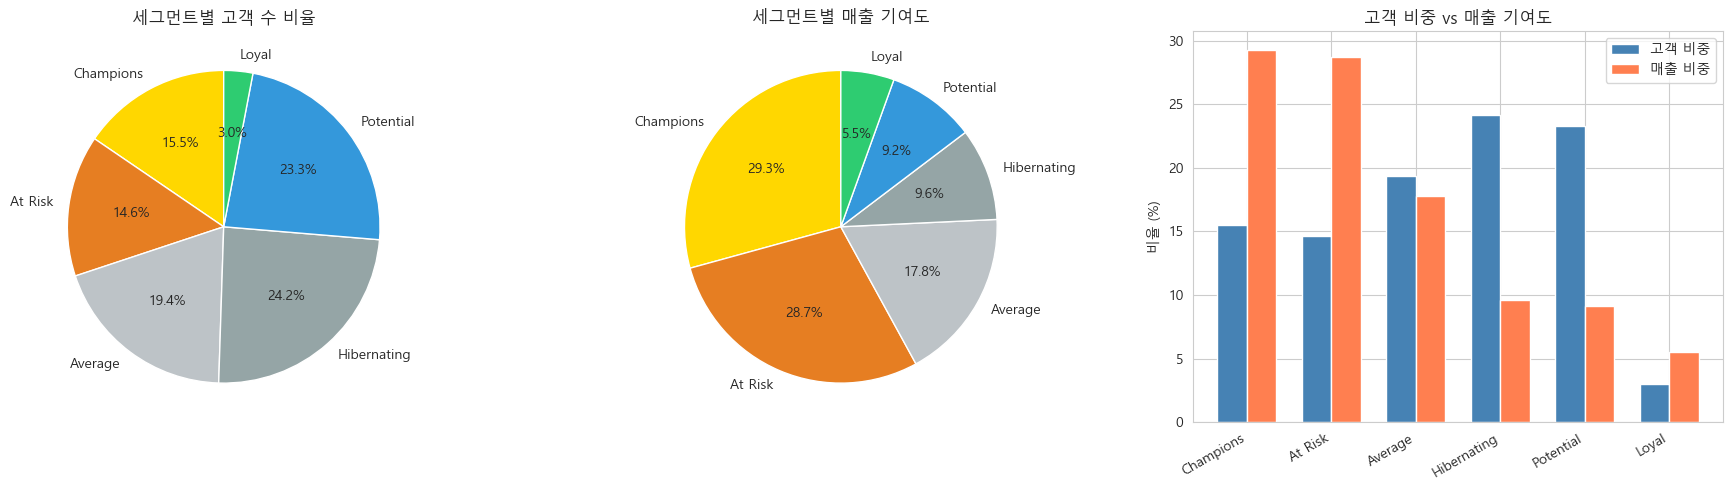

In [31]:
# 세그먼트 시각화
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

colors_map = {
    'Champions': '#FFD700',
    'Loyal': '#2ECC71',
    'Potential': '#3498DB',
    'At Risk': '#E67E22',
    'Hibernating': '#95A5A6',
    'Average': '#BDC3C7',
}

segments_order = seg_summary.index.tolist()
colors = [colors_map.get(s, 'gray') for s in segments_order]

# 고객 수 비율
axes[0].pie(seg_summary['고객수'], labels=segments_order, autopct='%1.1f%%', 
            colors=colors, startangle=90)
axes[0].set_title('세그먼트별 고객 수 비율')

# 매출 기여도
axes[1].pie(seg_summary['매출비중(%)'], labels=segments_order, autopct='%1.1f%%',
            colors=colors, startangle=90)
axes[1].set_title('세그먼트별 매출 기여도')

# 비교 막대
x = np.arange(len(segments_order))
width = 0.35

cust_pct = seg_summary['고객비중(%)'].values
rev_pct = seg_summary['매출비중(%)'].values

axes[2].bar(x - width/2, cust_pct, width, label='고객 비중', color='steelblue')
axes[2].bar(x + width/2, rev_pct, width, label='매출 비중', color='coral')
axes[2].set_xticks(x)
axes[2].set_xticklabels(segments_order, rotation=30, ha='right')
axes[2].set_ylabel('비율 (%)')
axes[2].set_title('고객 비중 vs 매출 기여도')
axes[2].legend()

plt.tight_layout()
plt.savefig('../images/rfm_segments.png', dpi=150, bbox_inches='tight')
plt.show()

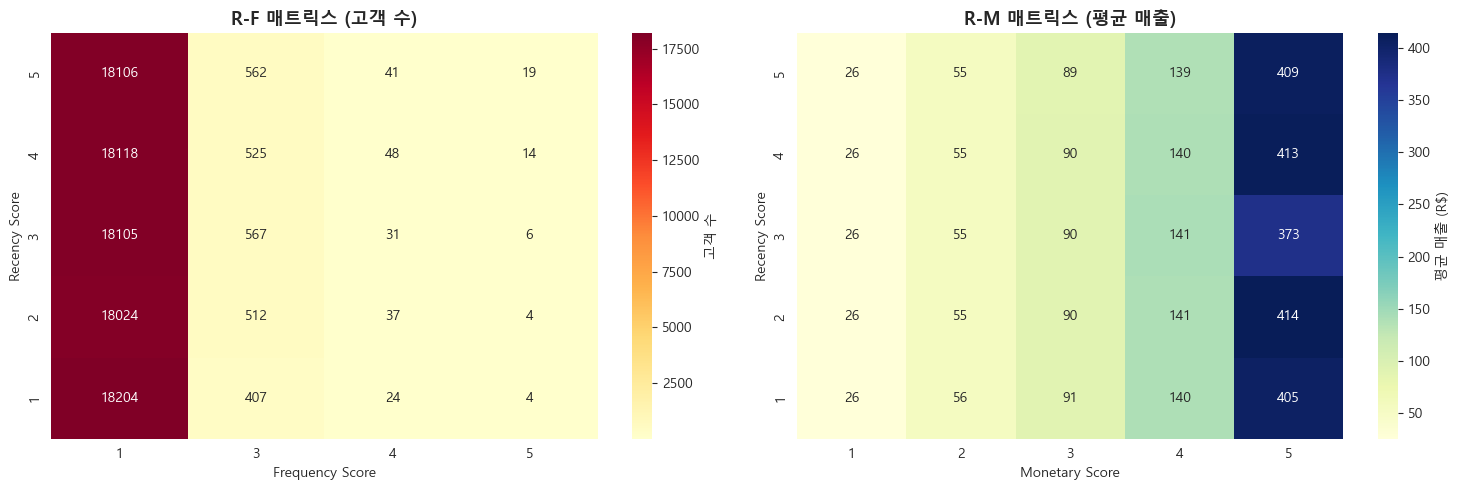

In [32]:
# R-F 매트릭스 히트맵 (가장 클래식한 RFM 시각화)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1) R-F 매트릭스 (고객 수)
rf_matrix = rfm.groupby(['R_Score', 'F_Score']).size().unstack(fill_value=0)
sns.heatmap(rf_matrix, annot=True, fmt='d', cmap='YlOrRd', 
            cbar_kws={'label': '고객 수'}, ax=axes[0])
axes[0].set_title('R-F 매트릭스 (고객 수)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Frequency Score')
axes[0].set_ylabel('Recency Score')
axes[0].invert_yaxis()  # R=5(최근)가 위로

# 2) R-M 매트릭스 (평균 매출)
rm_matrix = rfm.pivot_table(index='R_Score', columns='M_Score', 
                              values='Monetary', aggfunc='mean')
sns.heatmap(rm_matrix, annot=True, fmt='.0f', cmap='YlGnBu',
            cbar_kws={'label': '평균 매출 (R$)'}, ax=axes[1])
axes[1].set_title('R-M 매트릭스 (평균 매출)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Monetary Score')
axes[1].set_ylabel('Recency Score')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

## 3. 세그먼트별 운영 전략

| 세그먼트 | 우선순위 | 액션 |
|---|---|---|
| Loyal | 최고 | 재구매 유도가 이미 작동한 그룹. VIP 혜택으로 lock-in |
| Champions | 매우 높음 | 최근/고액 단발 고객. 두 번째 구매 유도가 핵심 |
| At Risk | 높음 | 과거 고액 구매자. 재참여 캠페인 즉시 실행 |
| Potential | 중간 | 최근 첫 구매. 7~30일 내 후속 캠페인으로 Loyal 전환 시도 |
| Hibernating | 낮음 | 저비용 리타겟팅 (이메일/푸시) |
| Average | 낮음 | 일반 마케팅 |

### 핵심 인사이트
- 재구매 고객(Loyal)은 전체의 약 2.5%이지만 매출 기여도가 훨씬 큼
- F=1인 고객이 96%를 차지 -> "한 번 사고 안 오는 시장" 특성
- 이 시장에서는 첫 구매 후 두 번째 구매 유도가 가장 큰 레버리지

In [33]:
# RFM 결과 저장
rfm.to_csv('../data/rfm_result.csv', index=False)
print(f"저장 완료: {len(rfm):,}행")

저장 완료: 93,358행
